In order to derive the price of an option we need a stochastic model for the underlying stock. We search for models that both capture the statistical properties of the stock dynamics and fit into the mathematical theory of stochastic analysis. We shall see the strenghts and limits of the Black-Scholes model .

# The Black-Scholes Model
We need a model for the price S(t) of the underlying stock at all times t until exercice time T. The dynamic model of Black-Scholes is geometric Brownian motion aka lognormal process: S(t)=S(0)exp(mu*t+ sigma*B(t)) where mu the drift of the stock and sigma the volatility and B(t) is Brownian motion.

## Definition : Brownian motion
Brownian motion B(t) is a stochastic process such as B(0)=0 and such as :
-Independent increments: The rv B(t)-B(s) is independent from B(u)-B(v) for t>s>=u>v>=0
-Normal increments: The distribution of B(t)-B(s) is N(0,t-s) , only a funcion of t-s not t and s separately

N.B: a Levy process L(t) ànly verifies that B(t)-B(s) a function of t-s not necessarily normal

Therefore the expression inside the exp of S(t) becomes a normal distribution N(mu*t , sigma*sigma*t) , hence lognormal process.

Here we plot three simulated paths over time of Brownian motion , it is continuous(only Levy process to be so) but nowhere differentiable.

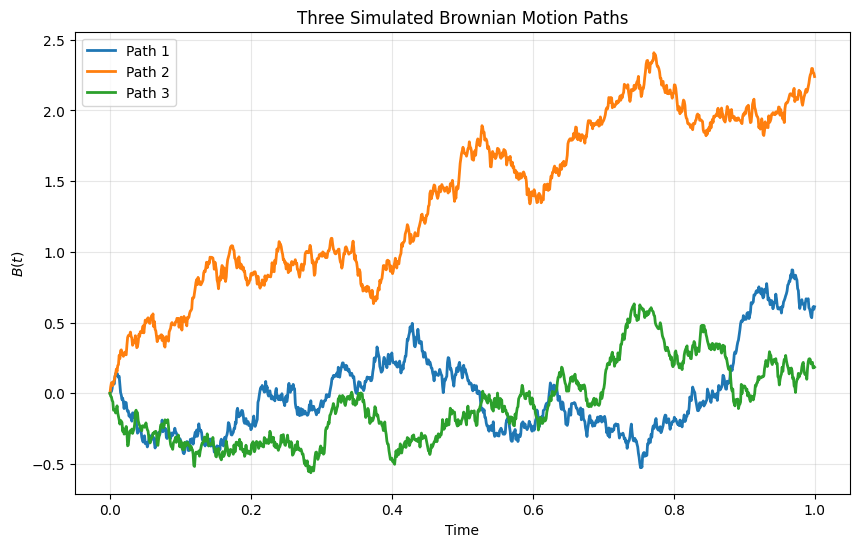

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)

# Parameters
T = 1.0          # Total time
N = 1000         # Number of time steps
dt = T / N       # Time step size
t = np.linspace(0, T, N + 1)

# Generate three Brownian motion paths
plt.figure(figsize=(10, 6))
#Why this works A Brownian motion satisfies B(ti+1)=B(ti)+ΔBi where each increment is independent and
#ΔBi∼N(0,Δt).

for i in range(3):
    # Brownian increments: N(0, dt)
    dB = np.sqrt(dt) * np.random.randn(N)

    # Brownian path
    B = np.concatenate(([0], np.cumsum(dB)))

    plt.plot(t, B, linewidth=2, label=f'Path {i+1}')

plt.title('Three Simulated Brownian Motion Paths')
plt.xlabel('Time')
plt.ylabel(r'$B(t)$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

We are going to analyse the FTSE and NASDAQ indexes. We collect from the Yahoo finance site daily , weekly and monthly closing values reigning from 1 January 2005 to 31 December 2017.

In [5]:
import yfinance as yf
import pandas as pd

# -------------------------------------------------------
# Parameters
# -------------------------------------------------------
start_date = "2005-01-01"
end_date = "2017-12-31"

tickers = {
    "FTSE": "^FTSE",      # FTSE 100 Index
    "NASDAQ": "^IXIC"     # NASDAQ Composite
}

# -------------------------------------------------------
# Download data
# -------------------------------------------------------
data = yf.download(
    list(tickers.values()),
    start=start_date,
    end="2018-01-01",      # end date is exclusive
    interval="1d",
    auto_adjust=False,
    progress=False
)

# Keep only closing prices
daily_close = data["Close"]

# Rename columns
daily_close.columns = tickers.keys()

# -------------------------------------------------------
# Weekly and Monthly closing prices
# -------------------------------------------------------
weekly_close = daily_close.resample("W-FRI").last()
monthly_close = daily_close.resample("ME").last()

# -------------------------------------------------------
# Save to CSV
# -------------------------------------------------------
daily_close.to_csv("daily_closing_prices.csv")
weekly_close.to_csv("weekly_closing_prices.csv")
monthly_close.to_csv("monthly_closing_prices.csv")

# -------------------------------------------------------
# Display information
# -------------------------------------------------------
print("Daily closing prices:")
print(daily_close.head())

print("\nWeekly closing prices:")
print(weekly_close.head())

print("\nMonthly closing prices:")
print(monthly_close.head())

print("\nNumber of observations")
print(f"Daily   : {len(daily_close)}")
print(f"Weekly  : {len(weekly_close)}")
print(f"Monthly : {len(monthly_close)}")

Daily closing prices:
                   FTSE       NASDAQ
Date                                
2005-01-03          NaN  2152.149902
2005-01-04  4847.000000  2107.860107
2005-01-05  4806.000000  2091.239990
2005-01-06  4824.299805  2090.000000
2005-01-07  4854.100098  2088.610107

Weekly closing prices:
                   FTSE       NASDAQ
Date                                
2005-01-07  4854.100098  2088.610107
2005-01-14  4820.799805  2087.909912
2005-01-21  4803.299805  2034.270020
2005-01-28  4832.799805  2035.829956
2005-02-04  4941.500000  2086.659912

Monthly closing prices:
                   FTSE       NASDAQ
Date                                
2005-01-31  4852.299805  2062.409912
2005-02-28  4968.500000  2051.719971
2005-03-31  4894.399902  1999.229980
2005-04-30  4801.700195  1921.650024
2005-05-31  4964.000000  2068.219971

Number of observations
Daily   : 3341
Weekly  : 678
Monthly : 156


# Logarithmic returns from stocks
Black Scholes assumed in their work that the returns from the stock are normally distributed, we will test this hypothesis and go into other aspects of the stochastic dynamics of the stock.

We define the return from an investment in the stock by

$$
y_i=\frac{S_i-S_{i-1}}{S_{i-1}}.
$$

We consider the logarithmic return

$$
x_i=\ln\left(\frac{S_i}{S_{i-1}}\right)
=\ln(S_i)-\ln(S_{i-1}).
$$

We observe the last trading price of the stock every day and remove weekends and holidays; thus, we ignore calendar time and operate only with trading days.

Under the Black--Scholes model, the logarithmic return over one time step satisfies

$$
X(t_i)=\mu\,\Delta T+\sigma\left(B(t_i)-B(t_{i-1})\right),
$$

where \(B(t)\) is a standard Brownian motion. Since

$$
B(t_i)-B(t_{i-1})\sim\mathcal{N}(0,\Delta T),
$$

it follows that

$$
X(t_i)\sim\mathcal{N}\left(\mu\Delta T,\sigma^2\Delta T\right),
$$

and the random variables \(X(t_i)\) are independent and identically distributed (i.i.d.).

Hence, it becomes straightforward to estimate \(\mu\) and \(\sigma\) using the maximum likelihood estimator (MLE). The estimators are

$$
\hat{\mu}
=
\frac{1}{N\Delta T}
\sum_{i=1}^{N}x_i,
$$

and

$$
\hat{\sigma}^{\,2}
=
\frac{1}{(N-1)\Delta T}
\sum_{i=1}^{N}\left(x_i-\hat{\mu}\Delta T\right)^2.
$$

We plot the empirical density of the daily log returns for the FTSE and NASDAQ indexes (using a Gaussian kernel smoother as a non-parametric estimator of the empirical density) alongside the normal distributions with parameters estimated using the MLE approach.


FTSE
mu_daily    = 0.00006747
sigma_daily = 0.01155387
annual return    = 1.70020633%
volatility = 18.34120737%

NASDAQ
mu_daily    = 0.00040253
sigma_daily = 0.01289868
annual return    = 10.14363590%
volatility = 20.47602716%


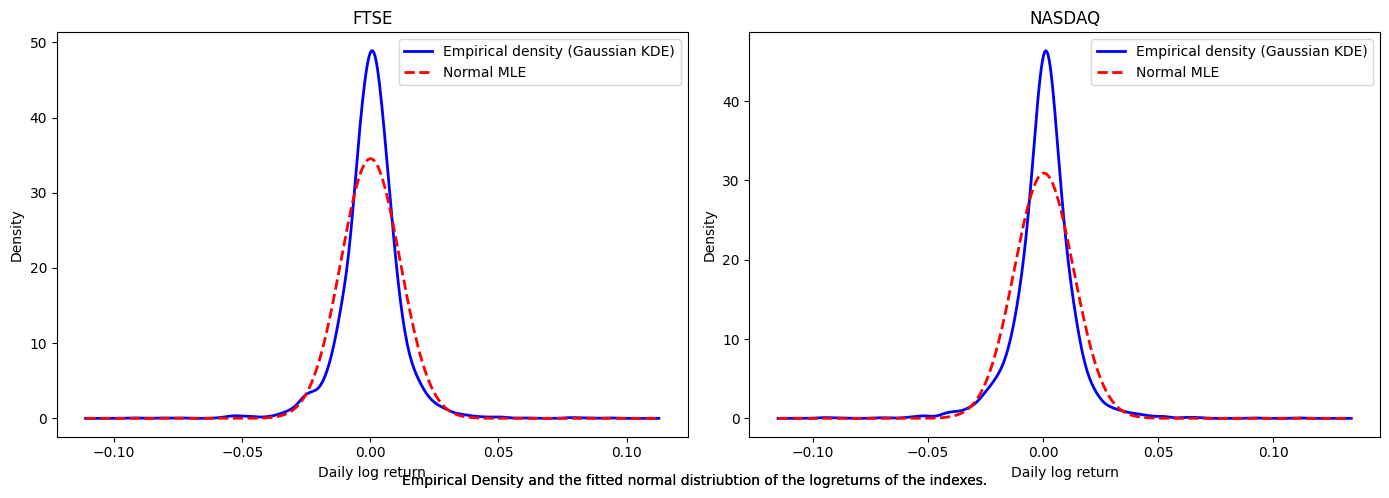

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, norm

# -------------------------------------------------------
# Daily logarithmic returns
# -------------------------------------------------------
log_returns = np.log(daily_close / daily_close.shift(1)).dropna()

delta_T = 1/252          # one trading day
N = len(log_returns)

# -------------------------------------------------------
# Plot empirical density vs fitted normal
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, index_name in zip(axes, log_returns.columns):

    x = log_returns[index_name].dropna().values
    n = len(x)

    # -------------------------------
    # MLE estimates
    # -------------------------------
    mu_hat = np.sum(x) / (n * delta_T) # ANNUAL drift

    sigma_hat = np.sqrt(
        np.sum((x - mu_hat*delta_T)**2) / ((n - 1) * delta_T)
    ) # ANNUAL volatility

    # -------------------------------
    # Empirical density (Gaussian KDE)
    # -------------------------------
    kde = gaussian_kde(x, bw_method='silverman')
    xmin = x.min() * 1.2
    xmax = x.max() * 1.2

    xx = np.linspace(xmin, xmax, 500)

    # KDE
    ax.plot(
        xx,
        kde(xx),
        color="blue",
        lw=2,
        label="Empirical density (Gaussian KDE)"
    )

    # Normal density with estimated parameters
    mu_daily = mu_hat * delta_T
    sigma_daily = sigma_hat * np.sqrt(delta_T)

    print(f"\n{index_name}")
    print(f"mu_daily    = {mu_daily:.8f}")
    print(f"sigma_daily = {sigma_daily:.8f}")
    print(f"annual return    = {mu_hat*100:.8f}%")
    print(f"volatility = {sigma_hat*100:.8f}%")



    ax.plot(
        xx,
        norm.pdf(xx, loc=mu_daily, scale=sigma_daily),
        color="red",
        linestyle="--",
        lw=2,
        label="Normal MLE"
    )

    ax.set_title(index_name)
    ax.set_xlabel("Daily log return")
    ax.set_ylabel("Density")
    ax.legend()
    fig.text(
    0.5, 0.02,
    "Empirical Density and the fitted normal distriubtion of the logreturns of the indexes.",
    ha="center",
    fontsize=10)


plt.tight_layout()
plt.show()

Logarithmic Scale for better visualisation

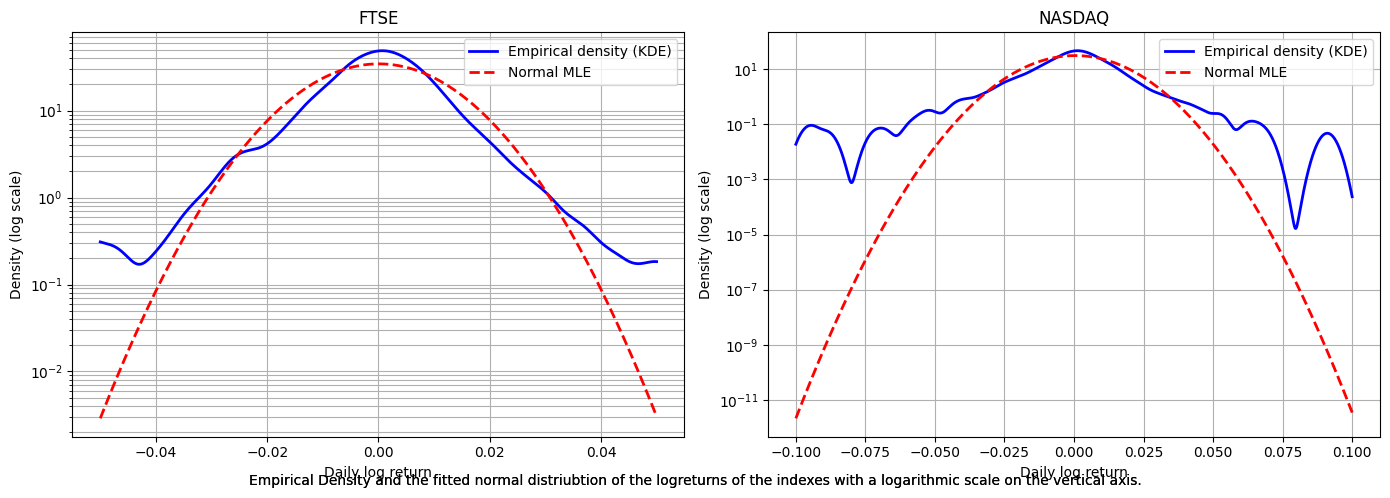

In [7]:
# -------------------------------------------------------
# Same plots with logarithmic y-axis
# -------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, index_name in zip(axes, log_returns.columns):

    x = log_returns[index_name].dropna().values

    # Daily MLE estimates
    mu_hat = np.mean(x)
    sigma_hat = np.std(x, ddof=1)

    # KDE
    kde = gaussian_kde(x, bw_method='silverman')

    if index_name == "FTSE":
        xx = np.linspace(-0.05, 0.05, 1000)
    else:
        xx = np.linspace(-0.10, 0.10, 1000)

    # Density values
    kde_vals = kde(xx)
    normal_vals = norm.pdf(xx, loc=mu_hat, scale=sigma_hat)

    # Log scale cannot handle zero
    eps = 1e-12
    kde_vals = np.maximum(kde_vals, eps)
    normal_vals = np.maximum(normal_vals, eps)

    # Plot
    ax.plot(
        xx,
        kde_vals,
        color="blue",
        lw=2,
        label="Empirical density (KDE)"
    )

    ax.plot(
        xx,
        normal_vals,
        color="red",
        linestyle="--",
        lw=2,
        label="Normal MLE"
    )

    # Logarithmic vertical axis
    ax.set_yscale("log")

    ax.set_title(index_name)
    ax.set_xlabel("Daily log return")
    ax.set_ylabel("Density (log scale)")
    ax.legend()
    ax.grid(True, which="both")
    fig.text(
    0.5, 0.02,
    "Empirical Density and the fitted normal distriubtion of the logreturns of the indexes with a logarithmic scale on the vertical axis.",
    ha="center",
    fontsize=10)


plt.tight_layout()
plt.show()

# Scaling towards normality
From the additivity property of the logarithmic returns, the weekly and monthly log returns are defined by

$$
x_i^{(w)}
=
\sum_{k=1}^{5}
x_{5(i-1)+k},
$$

and

$$
x_i^{(m)}
=
\sum_{k=1}^{20}
x_{20(i-1)+k}.
$$
Therefore if we suppose that the logreturns are iid , the central limit theorem implies that the weekly and monthly logreturns tend to a normal distribution.
We will plot the empirical density (kernel method) for the FTSE index observed weekly and monthly together with the fitted normal distribution.


NASDAQ Weekly
Mean      = 0.001766
Std. dev. = 0.025900

NASDAQ Monthly
Mean      = 0.007794
Std. dev. = 0.047749


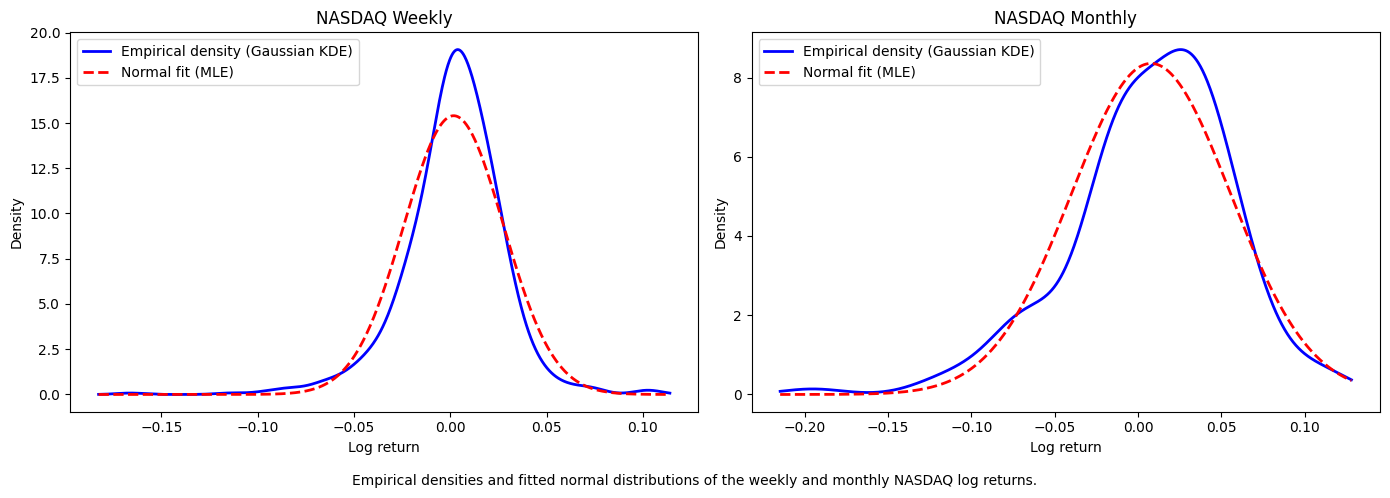

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, norm

# -------------------------------------------------------
# Weekly and Monthly NASDAQ log returns
# -------------------------------------------------------
weekly_returns = np.log(weekly_close["NASDAQ"] / weekly_close["NASDAQ"].shift(1)).dropna()
monthly_returns = np.log(monthly_close["NASDAQ"] / monthly_close["NASDAQ"].shift(1)).dropna()

returns = {
    "Weekly": weekly_returns,
    "Monthly": monthly_returns
}

# -------------------------------------------------------
# Plot
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (period, series) in zip(axes, returns.items()):

    x = series.values

    # Daily-unit MLE estimates
    mu_hat = np.mean(x)
    sigma_hat = np.std(x, ddof=1)

    print(f"\nNASDAQ {period}")
    print(f"Mean      = {mu_hat:.6f}")
    print(f"Std. dev. = {sigma_hat:.6f}")

    # Kernel density estimate
    kde = gaussian_kde(x, bw_method='silverman')

    xmin = x.min() * 1.1
    xmax = x.max() * 1.1
    xx = np.linspace(xmin, xmax, 1000)

    ax.plot(
        xx,
        kde(xx),
        color="blue",
        lw=2,
        label="Empirical density (Gaussian KDE)"
    )

    ax.plot(
        xx,
        norm.pdf(xx, mu_hat, sigma_hat),
        color="red",
        linestyle="--",
        lw=2,
        label="Normal fit (MLE)"
    )

    ax.set_title(f"NASDAQ {period}")
    ax.set_xlabel("Log return")
    ax.set_ylabel("Density")
    ax.legend()

fig.text(
    0.5,
    0.02,
    "Empirical densities and fitted normal distributions of the weekly and monthly NASDAQ log returns.",
    ha="center",
    fontsize=10,
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

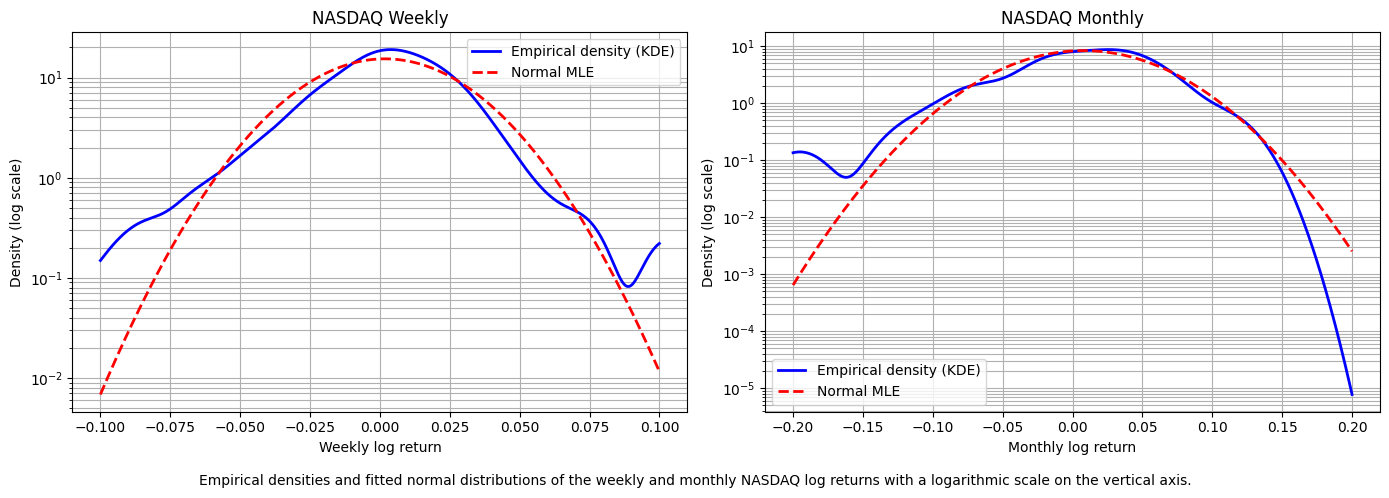

In [11]:
# -------------------------------------------------------
# Weekly and Monthly log returns (logarithmic y-axis)
# -------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

returns = {
    "Weekly": weekly_returns,
    "Monthly": monthly_returns
}

for ax, (period, series) in zip(axes, returns.items()):

    x = series.values

    # MLE estimates
    mu_hat = np.mean(x)
    sigma_hat = np.std(x, ddof=1)

    # KDE
    kde = gaussian_kde(x, bw_method='silverman')

    if period == "Weekly":
        xx = np.linspace(-0.10, 0.10, 1000)
    else:  # Monthly
        xx = np.linspace(-0.20, 0.20, 1000)

    # Density values
    kde_vals = kde(xx)
    normal_vals = norm.pdf(xx, loc=mu_hat, scale=sigma_hat)

    # Log scale cannot handle zero
    eps = 1e-12
    kde_vals = np.maximum(kde_vals, eps)
    normal_vals = np.maximum(normal_vals, eps)

    # Plot
    ax.plot(
        xx,
        kde_vals,
        color="blue",
        lw=2,
        label="Empirical density (KDE)"
    )

    ax.plot(
        xx,
        normal_vals,
        color="red",
        linestyle="--",
        lw=2,
        label="Normal MLE"
    )

    ax.set_yscale("log")

    ax.set_title(f"NASDAQ {period}")
    ax.set_xlabel(f"{period} log return")
    ax.set_ylabel("Density (log scale)")
    ax.legend()
    ax.grid(True, which="both")

fig.text(
    0.5,
    0.02,
    "Empirical densities and fitted normal distributions of the weekly and monthly NASDAQ log returns with a logarithmic scale on the vertical axis.",
    ha="center",
    fontsize=10
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

Comparing with daily observations, one observes a convergence towards normal distribution.

# Heavy-tailed and skewed logreturns
We will use quantiles to measure how heavy the tails are for the logreturns of the two indexes considered. A heavy-tailed distribution will have larger quantiles than the normal because it assigns more probability to extreme events.


In [12]:
import numpy as np
from scipy.stats import norm

# -------------------------------------------------------
# Daily logarithmic returns
# -------------------------------------------------------
log_returns = np.log(daily_close / daily_close.shift(1)).dropna()

# Quantiles to compare
quantile_levels = [0.01, 0.02, 0.98, 0.99]

for index_name in log_returns.columns:

    x = log_returns[index_name].dropna().values

    # MLE estimates (daily)
    mu_hat = np.mean(x)
    sigma_hat = np.std(x, ddof=1)

    # Empirical quantiles
    empirical = np.quantile(x, quantile_levels)

    # Corresponding normal quantiles
    normal = norm.ppf(quantile_levels, loc=mu_hat, scale=sigma_hat)

    print(f"\n{'='*55}")
    print(f"{index_name} Daily Log Returns")
    print(f"{'='*55}")
    print(f"{'Quantile':>10} {'Empirical':>15} {'Normal (MLE)':>15}")
    print("-"*45)

    for q, e, n in zip(quantile_levels, empirical, normal):
        print(f"{q:>8.0%} {e:>15.6f} {n:>15.6f}")


FTSE Daily Log Returns
  Quantile       Empirical    Normal (MLE)
---------------------------------------------
      1%       -0.031941       -0.026811
      2%       -0.026067       -0.023661
     98%        0.023891        0.023796
     99%        0.030355        0.026946

NASDAQ Daily Log Returns
  Quantile       Empirical    Normal (MLE)
---------------------------------------------
      1%       -0.038443       -0.029604
      2%       -0.029408       -0.026088
     98%        0.027376        0.026893
     99%        0.034998        0.030409


For the both indexes the difference is more apparent for the 1% quantile. There are signs of heavy tails also in the 2% and 99% quantiles for both indexes. The normal distribution consistently underestimates the probability for extreme events.
How critical is this underestimation? Let us say we would like to find out how many times a year the logreturn of FTSE drops more than -0.03. Empirically this happens in 1% of all trading days a year, that is on average five times in two years. If we believe in the fitted normal distribution, the estimated probability of a logreturn being less than -0.03 is approximately 0.2%, which is only once in two years!




However, this comparison alone does not reveal whether the distribution is **symmetric**. To investigate this property, we study the **skewness** of the distribution.

A normal distribution is perfectly symmetric about its mean. Consequently, events that are equally far into the left and right tails should have similar probabilities. If the empirical distribution is skewed, however, one tail will contain more probability mass than the other, and the normal distribution will fail to capture this asymmetry.

Let $q_{0.01}^{\mathrm{emp}}$ and $q_{0.99}^{\mathrm{emp}}$ denote the empirical 1% and 99% quantiles of the daily log returns. By definition,

$$
P(X < q_{0.01}^{\mathrm{emp}}) = 0.01,
$$

and

$$
P(X > q_{0.99}^{\mathrm{emp}}) = 0.01.
$$

These thresholds are determined directly from the observed data.

Next, we consider the fitted normal distribution obtained by maximum likelihood estimation. Instead of computing its own theoretical quantiles, we evaluate the probabilities assigned by the normal distribution to these **empirical thresholds**:

$$
P_N\!\left(X < q_{0.01}^{\mathrm{emp}}\right),
$$

and

$$
P_N\!\left(X > q_{0.99}^{\mathrm{emp}}\right),
$$

where $P_N$ denotes probabilities under the fitted normal distribution.

If the normal model were an accurate description of the data, both probabilities would be close to 1%, since the empirical 1% and 99% quantiles should approximately coincide with the corresponding quantiles of the fitted Gaussian distribution.

In practice, this is generally not the case. For example, the fitted normal distribution may assign only **0.2%** probability to returns below the empirical 1% quantile and **0.4%** probability to returns above the empirical 99% quantile. Although both probabilities are smaller than the expected 1%, they are not equal. The Gaussian model therefore predicts that extreme positive returns are approximately twice as likely as extreme negative returns at these thresholds.

This discrepancy indicates that the empirical distribution is **not symmetric** in the same way as a Gaussian distribution. In other words, the normal model fails to reproduce the relative behaviour of the two tails. Such differences are a manifestation of **skewness**, meaning that one tail of the distribution differs from the other in shape or probability mass.

Studying these probabilities therefore complements the quantile analysis. While the quantiles reveal the presence of **heavy tails**, the probabilities assigned by the fitted normal distribution to the empirical extreme quantiles reveal the **asymmetry** between the left and right tails, highlighting another important limitation of the Gaussian assumption for modelling stock log returns.


# Logreturns and the Normal Inverse Gaussian Distribution

The normal distribution is not a good model for log returns over short time intervals, as it cannot capture the observed heavy tails and has no flexibility towards asymmetry.

We are going to present the Normal Inverse Gaussian (NIG) distribution. The NIG distribution has four parameters: $\alpha$, $\beta$, $\mu$ and $\delta$.

The parameter $\mu$ describes where the distribution is centered on the real line, while the skewness is controlled by $\beta$ ($\beta>0$ when the distribution is skewed to the right and $\beta<0$ when it is skewed to the left). The parameter $\delta$ is the scale parameter and plays a role similar to the standard deviation of the normal distribution. The tail heaviness is controlled by the parameter $\alpha$.

We exhibit four examples of the NIG distribution for different choices of the parameters. All distributions are centered with $\mu=0$ and $\delta=0.015$. The variation of the tail heaviness can be observed in the first two plots. When $\alpha=30$, the tails have a heavy hyperbolic shape, whereas for $\alpha=150$ they become much closer to those of a normal distribution.

The last two plots illustrate the effect of the skewness parameter by considering $\beta=10$ and $\beta=-10$.

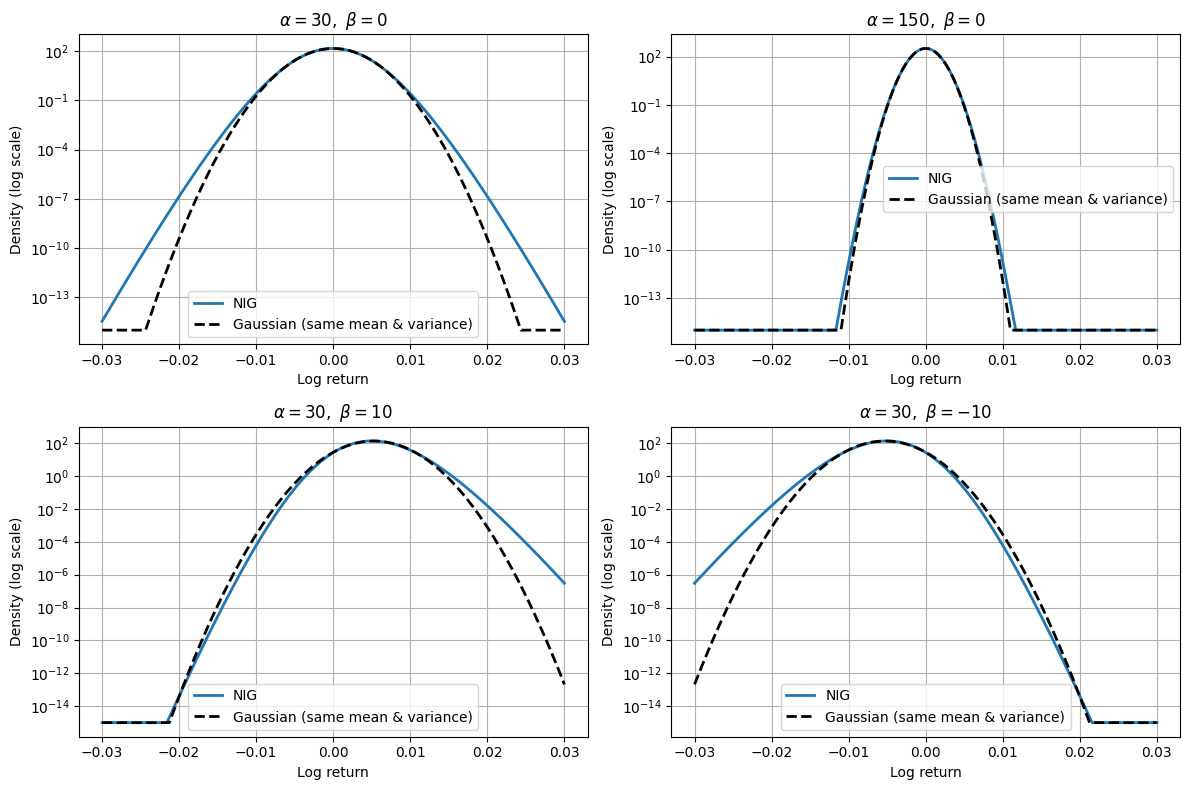

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norminvgauss, norm

# -------------------------------------------------------
# Parameters
# -------------------------------------------------------
delta = 0.015
mu = 0

examples = [
    {"alpha": 30,  "beta": 0,   "title": r"$\alpha=30,\ \beta=0$"},
    {"alpha": 150, "beta": 0,   "title": r"$\alpha=150,\ \beta=0$"},
    {"alpha": 30,  "beta": 10,  "title": r"$\alpha=30,\ \beta=10$"},
    {"alpha": 30,  "beta": -10, "title": r"$\alpha=30,\ \beta=-10$"},
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

x = np.linspace(-0.03, 0.03, 1000)

for ax, params in zip(axes.ravel(), examples):

    alpha = params["alpha"]
    beta = params["beta"]

    # -----------------------------
    # NIG density
    # -----------------------------
    nig_pdf = norminvgauss.pdf(
        x,
        a=alpha,
        b=beta,
        loc=mu,
        scale=delta
    )

    # Matching Gaussian
    mean, variance = norminvgauss.stats(
    a=alpha,
    b=beta,
    loc=mu,
    scale=delta,
    moments='mv')

    mean = float(mean)
    std = float(np.sqrt(variance))


    gaussian_pdf = norm.pdf(x, loc=mean, scale=std)
    # Avoid zeros on log scale
    nig_pdf = np.clip(nig_pdf, 1e-15, None)
    gaussian_pdf = np.clip(gaussian_pdf, 1e-15, None)

    # Plot
    ax.plot(
        x,
        nig_pdf,
        lw=2,
        label="NIG"
    )

    ax.plot(
        x,
        gaussian_pdf,
        "k--",
        lw=2,
        label="Gaussian (same mean & variance)"
    )

    ax.set_yscale("log")

    ax.set_title(params["title"])
    ax.set_xlabel("Log return")
    ax.set_ylabel("Density (log scale)")
    ax.grid(True, which="both")
    ax.legend()

plt.tight_layout()
plt.show()

Since the density of the NIG distribution is known, we could perform maximum likelihood estimation to estimate its parameters. However, unlike the Gaussian case, the likelihood equations do not admit an explicit analytical solution. We therefore estimate the parameters numerically by maximizing the log-likelihood using the optimization routines implemented in SciPy.

The maximum likelihood estimates for the FTSE and NASDAQ indexes are computed for the daily, weekly and monthly log returns.

  Frequency   Index    alpha      beta       mu    delta
0     Daily    FTSE 0.502520 -0.047212 0.000824 0.008014
1     Daily  NASDAQ 0.424766 -0.056198 0.001508 0.008279
2    Weekly    FTSE 0.794672 -0.159817 0.004851 0.020320
3    Weekly  NASDAQ 0.854039 -0.192538 0.007064 0.022894
4   Monthly    FTSE 4.403238 -2.138907 0.039066 0.064954
5   Monthly  NASDAQ 2.352826 -1.022948 0.038102 0.062774


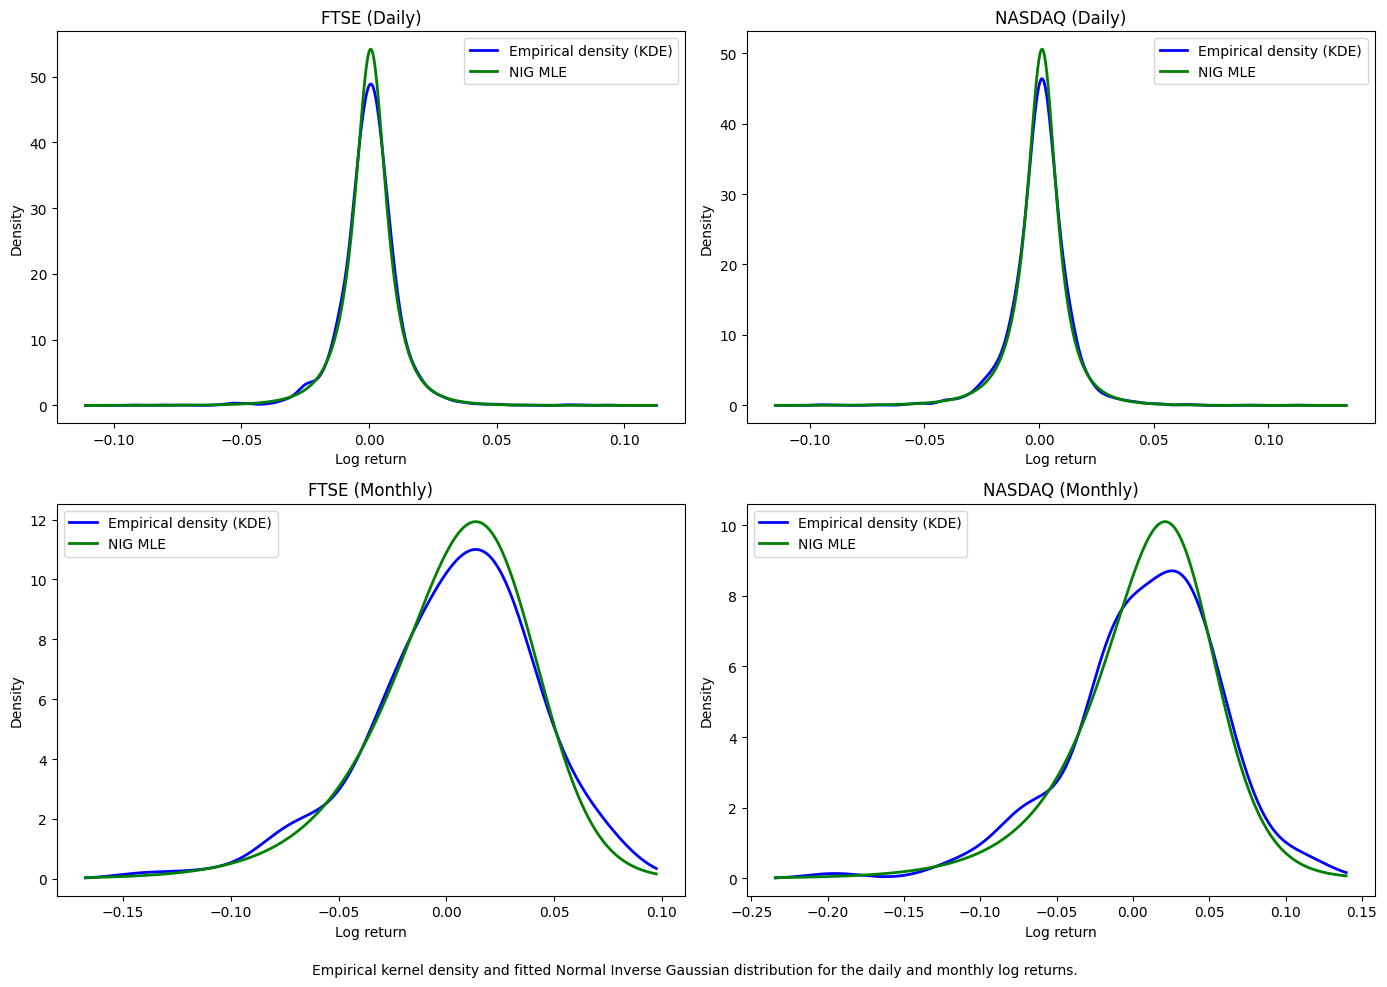

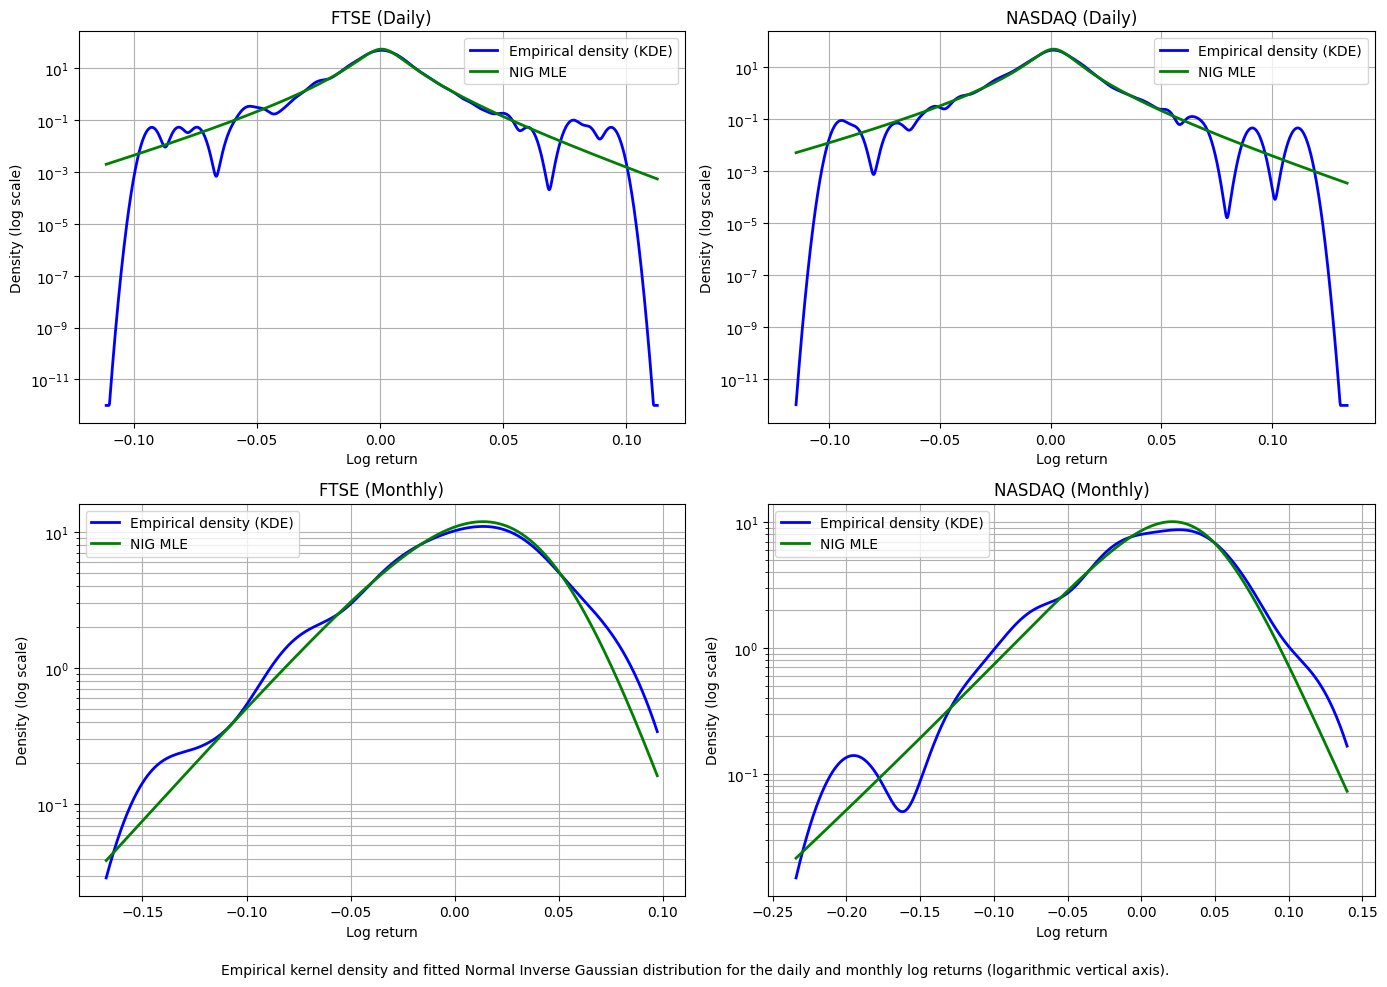

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, norm, norminvgauss

# -------------------------------------------------------
# Log returns
# -------------------------------------------------------
daily_returns = np.log(daily_close / daily_close.shift(1)).dropna()
weekly_returns = np.log(weekly_close / weekly_close.shift(1)).dropna()
monthly_returns = np.log(monthly_close / monthly_close.shift(1)).dropna()

datasets = {
    "Daily": daily_returns,
    "Weekly": weekly_returns,
    "Monthly": monthly_returns
}

# -------------------------------------------------------
# NIG Maximum Likelihood Estimation
# -------------------------------------------------------

results = []

for frequency, df in datasets.items():

    for index_name in df.columns:

        x = df[index_name].dropna().values

        # NIG MLE
        alpha, beta, loc, delta = norminvgauss.fit(x)

        results.append([
            frequency,
            index_name,
            alpha,
            beta,
            loc,
            delta
        ])

results = pd.DataFrame(
    results,
    columns=[
        "Frequency",
        "Index",
        "alpha",
        "beta",
        "mu",
        "delta"
    ]
)

pd.set_option("display.float_format", "{:.6f}".format)

print(results)

# -------------------------------------------------------
# Plot empirical KDE, Gaussian MLE and NIG MLE
# (Daily and Monthly only)
# -------------------------------------------------------

plot_sets = {
    "Daily": daily_returns,
    "Monthly": monthly_returns
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, (frequency, df) in enumerate(plot_sets.items()):

    for col, index_name in enumerate(df.columns):

        ax = axes[row, col]

        x = df[index_name].dropna().values

        # KDE
        kde = gaussian_kde(x, bw_method="silverman")

        # NIG MLE
        alpha, beta, loc, delta = norminvgauss.fit(x)

        # Plotting grid
        xx = np.linspace(x.min()*1.2, x.max()*1.2, 1000)

        # Plot KDE
        ax.plot(
            xx,
            kde(xx),
            color="blue",
            lw=2,
            label="Empirical density (KDE)"
        )


        # Plot NIG
        ax.plot(
            xx,
            norminvgauss.pdf(
                xx,
                a=alpha,
                b=beta,
                loc=loc,
                scale=delta
            ),
            color="green",
            lw=2,
            label="NIG MLE"
        )

        ax.set_title(f"{index_name} ({frequency})")
        ax.set_xlabel("Log return")
        ax.set_ylabel("Density")
        ax.legend()

fig.text(
    0.5,
    0.02,
    "Empirical kernel density and fitted Normal Inverse Gaussian distribution for the daily and monthly log returns.",
    ha="center",
    fontsize=10
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()
# -------------------------------------------------------
# Same plots with logarithmic y-axis
# -------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, (frequency, df) in enumerate(plot_sets.items()):

    for col, index_name in enumerate(df.columns):

        ax = axes[row, col]

        x = df[index_name].dropna().values

        # KDE
        kde = gaussian_kde(x, bw_method="silverman")


        # NIG MLE
        alpha, beta, loc, delta = norminvgauss.fit(x)

        # Plotting grid
        xx = np.linspace(x.min()*1.2, x.max()*1.2, 1000)

        # Evaluate densities
        kde_vals = kde(xx)
        nig_vals = norminvgauss.pdf(
            xx,
            a=alpha,
            b=beta,
            loc=loc,
            scale=delta
        )

        # Avoid zeros for log-scale
        eps = 1e-12
        kde_vals = np.maximum(kde_vals, eps)
        nig_vals = np.maximum(nig_vals, eps)

        # Plot
        ax.plot(
            xx,
            kde_vals,
            color="blue",
            lw=2,
            label="Empirical density (KDE)"
        )

        ax.plot(
            xx,
            nig_vals,
            color="green",
            lw=2,
            label="NIG MLE"
        )

        ax.set_yscale("log")

        ax.set_title(f"{index_name} ({frequency})")
        ax.set_xlabel("Log return")
        ax.set_ylabel("Density (log scale)")
        ax.grid(True, which="both")
        ax.legend()

fig.text(
    0.5,
    0.02,
    "Empirical kernel density and fitted Normal Inverse Gaussian distribution for the daily and monthly log returns (logarithmic vertical axis).",
    ha="center",
    fontsize=10
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

We notice how the NIG distribution fits the empirical in the tails and with respect to the skeweness 

# An Alternative to the Black–Scholes Model?

We saw that the normal distribution, contrary to the NIG distribution, is not a very good model for the log returns of stocks. We will consider what kind of stock dynamics lead to an NIG model for the log returns.

If we consider price dynamics of the form

$$
S(t)=S(0)e^{L(t)},
$$

where $L(t)$ is a Lévy process such that the increments

$$
L(t)-L(s)
$$

follow a Normal Inverse Gaussian (NIG) distribution, then the resulting process is called a **Normal Inverse Gaussian Lévy process**.

The random variables

$$
X_i=\log\!\left(\frac{S(t_i)}{S(t_{i-1})}\right)
$$

are the increments of the Lévy process,

$$
X_i=L(t_i)-L(t_{i-1}),
$$

and therefore have the same distribution as $L(1)$. Consequently, the parameters of $L(1)$ can be estimated from the observed log return data using the scaling properties of the NIG Lévy process.

In contrast to Brownian motion, the Normal Inverse Gaussian Lévy process has discontinuous sample paths. This implies that the price path of $S(t)$ is not continuous, but instead may jump upward or downward at random times.

# Autocorrelation of logreturns
The Black-Scholes model predicts independent logreturns. If this isn't true one could start to predict future returns from historical ones. This sounds very unlikely in liquid markets. However in stock markets we often observe that the price fluctuations cluster into periods with large movements and periods with smaller movements. It seems to be that the sizes of the logreturns could be dependant. We will confirm this empirically and analyse it.

The Black-Scholes model assumes that successive logreturns are independent. Under this assumption, the autocorrelation of the return series should be approximately zero for every lag:

$$
\mathrm{Corr}(X_t, X_{t+s}) = 0, \qquad s \geq 1,
$$

where $X_t$ denotes the logreturn at time $t$.

To test this assumption, we compute the empirical autocorrelation of the FTSE daily logreturns. If the Black-Scholes assumption is correct, the sample autocorrelations should fluctuate randomly around zero, indicating that past returns provide no information about future returns.

However, financial markets often exhibit **volatility clustering**: periods of high volatility tend to be followed by high volatility, while calm periods tend to be followed by calm periods. This dependence is not visible in the returns themselves because positive and negative returns cancel each other out.

To reveal this phenomenon, we also compute the autocorrelation of

- the absolute logreturns,

$$
|X_t|,
$$

- the squared logreturns,

$$
X_t^2.
$$

If volatility clustering exists, these transformed series should exhibit positive autocorrelation over many lags, even though the original logreturns remain essentially uncorrelated.



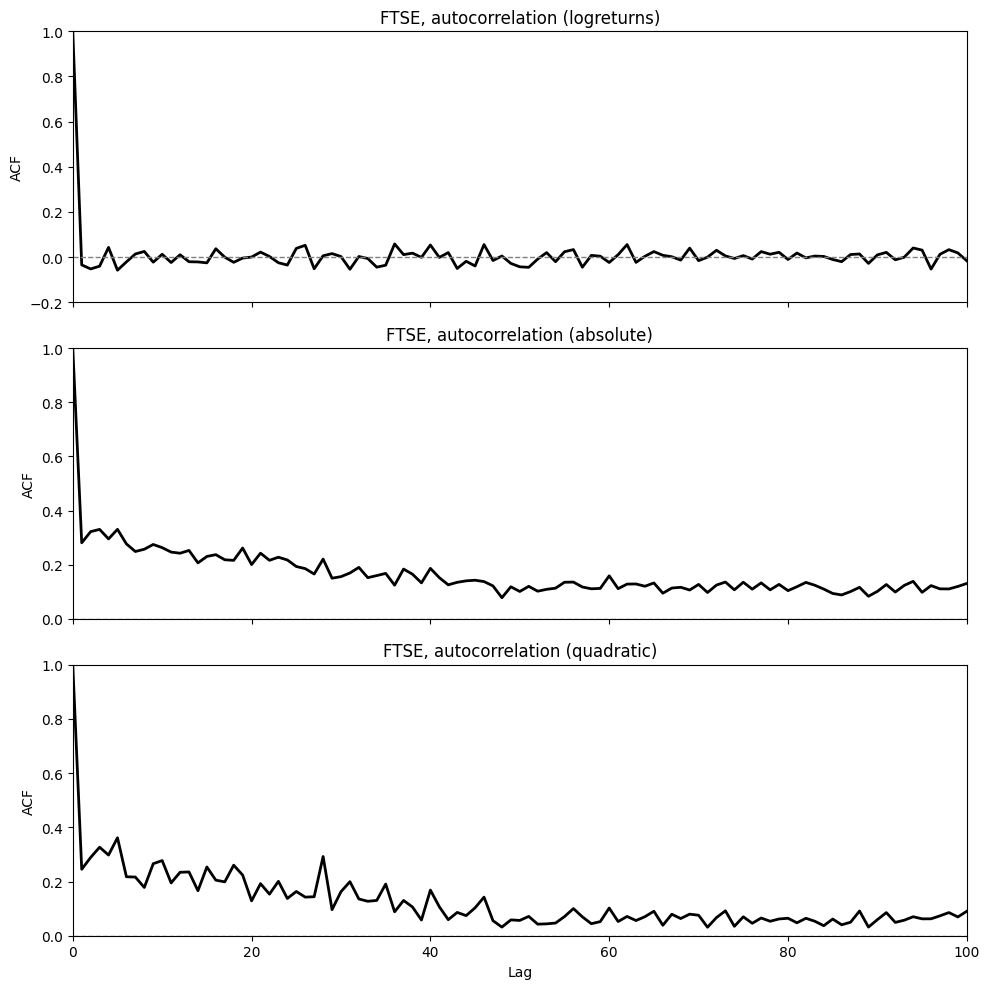

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf

# -------------------------------------------------------
# Compute FTSE daily logreturns
# -------------------------------------------------------
ftse = daily_close["FTSE"].dropna()

# Logreturns
r = np.log(ftse).diff().dropna()

# Absolute and squared logreturns
abs_r = np.abs(r)
sq_r = r**2

# -------------------------------------------------------
# Compute autocorrelation functions
# -------------------------------------------------------
nlags = 100

acf_r = acf(r, nlags=nlags, fft=True)
acf_abs = acf(abs_r, nlags=nlags, fft=True)
acf_sq = acf(sq_r, nlags=nlags, fft=True)

lags = np.arange(nlags + 1)

# -------------------------------------------------------
# Plot
# -------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# Logreturns
axes[0].plot(lags, acf_r, color="black", linewidth=2)
axes[0].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[0].set_title("FTSE, autocorrelation (logreturns)")
axes[0].set_ylim(-0.2, 1.0)
axes[0].set_xlim(0, nlags)
axes[0].set_ylabel("ACF")

# Absolute logreturns
axes[1].plot(lags, acf_abs, color="black", linewidth=2)
axes[1].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("FTSE, autocorrelation (absolute)")
axes[1].set_ylim(0, 1.0)
axes[1].set_xlim(0, nlags)
axes[1].set_ylabel("ACF")

# Squared logreturns
axes[2].plot(lags, acf_sq, color="black", linewidth=2)
axes[2].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[2].set_title("FTSE, autocorrelation (quadratic)")
axes[2].set_ylim(0, 1.0)
axes[2].set_xlim(0, nlags)
axes[2].set_xlabel("Lag")
axes[2].set_ylabel("ACF")

plt.tight_layout()
plt.show()

The autocorrelation of the FTSE logreturns fluctuates around zero and is typically not statistically significant. This supports the Black-Scholes assumption that returns are approximately independent and therefore difficult to predict from past returns.

The situation changes when considering the absolute and squared logreturns. Both series exhibit positive autocorrelation across several lags, indicating that the **magnitude** of returns is persistent over time.

This phenomenon is known as **volatility clustering**: large price movements tend to be followed by large movements (of either sign), while small movements tend to be followed by small movements. Consequently, although the direction of future returns is largely unpredictable, the level of market volatility displays temporal dependence.

These empirical findings agree with the well-known stylized facts of financial time series and illustrate one of the main limitations of the Black-Scholes model, which assumes constant volatility and predicts zero autocorrelation even for transformed return series.

# Conclusion and openings
In this repository we will stick to stock price models which predict independent (absolute values and sqaures of) logreturns.While such models are empirically wrong they are not too bad as a first-step approximation.

As an idea for future repos, if we insist on including time dependencies in the stock price dynamics we could consider **stochastic volatility models**

Also Geometric Brownian motion cannot treat heavy tails and skeweness like the normal inverse Gaussian Lévy process does , however the analysis of option premiums based on Lévy processes is much more demanding theorertically and will be studied in a future project.

There are still many benefits to sticking to the good ol' geometric Brownian motion model as it leads to closed-form solutions of many options premiums and is able to model somewhat realistically the dynamical behaviour of many stocks and its shortcomings may be insignifiant compared to other assumptions we shall make in our framework (no transcation costs, all options can be perfectely replicated by stock speculation). We shall therefore assume a geometric Brownian motion dynamics for the price evolution of the stock underlying the option.